# 03 — Backtest de la stratégie momentum

**Projet** : Stratégie quantitative momentum sur le STOXX Europe 600  
**Auteur** : Volkan ISLEYEN  
**Date** : Mai 2026

## Objectif

Calculer la performance de la stratégie momentum (long-only, top quintile, rebalancement mensuel) sur 2016-2024, avec et sans coûts de transaction, puis la comparer au benchmark STOXX 600.

## Méthodologie

1. Calculer le rendement quotidien brut du portefeuille (poids × rendements)
2. Calculer le turnover à chaque rebalancement
3. Appliquer les coûts de transaction (15 bp par trade aller-retour)
4. Construire les courbes de performance cumulée
5. Comparer au benchmark STOXX 600

## Coûts de transaction

On retient un coût de **15 points de base par trade** (achat ou vente), 
appliqué au turnover à chaque rebalancement. C'est une hypothèse réaliste 
pour des actions européennes liquides de grande capitalisation.

## Données en entrée

- `data/processed/weights_momentum.csv` — matrice de poids
- `data/processed/returns_daily.csv` — rendements quotidiens
- `data/raw/benchmark_stoxx600.csv` — benchmark STOXX 600

In [1]:
# Librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')

# Chemins
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_RAW = PROJECT_ROOT / "data" / "raw"
FIGURES = PROJECT_ROOT / "output" / "figures"
TABLES = PROJECT_ROOT / "output" / "tables"

for d in [FIGURES, TABLES]:
    d.mkdir(parents=True, exist_ok=True)

# Chargement des données du notebook 02
weights = pd.read_csv(DATA_PROCESSED / "weights_momentum.csv", index_col=0, parse_dates=True)
returns = pd.read_csv(DATA_PROCESSED / "returns_daily.csv", index_col=0, parse_dates=True)
benchmark = pd.read_csv(DATA_RAW / "benchmark_stoxx600.csv", index_col=0, parse_dates=True)

print(f"Poids : {weights.shape}")
print(f"Rendements : {returns.shape}")
print(f"Benchmark : {benchmark.shape}")
print(f"\nPériode des poids : {weights.index.min().date()} → {weights.index.max().date()}")

Poids : (2586, 577)
Rendements : (2586, 577)
Benchmark : (2540, 2)

Période des poids : 2015-01-01 → 2024-12-30


In [2]:
# Calcul du rendement quotidien brut du portefeuille
# Rendement du portefeuille = somme pondérée des rendements des titres détenus
# Les poids du jour t s'appliquent aux rendements du jour t

# IMPORTANT : on utilise les poids de la VEILLE pour les rendements du jour
# (on détient le portefeuille construit hier, il génère le rendement d'aujourd'hui)
portfolio_returns = (weights.shift(1) * returns).sum(axis=1)

# On retire la période avant le premier investissement (rendements nuls)
portfolio_returns = portfolio_returns[portfolio_returns.index >= "2016-01-01"]

print(f"Rendements du portefeuille : {len(portfolio_returns)} jours")
print(f"Période : {portfolio_returns.index.min().date()} → {portfolio_returns.index.max().date()}")
print(f"\nStatistiques des rendements quotidiens (brut, en %) :")
print((portfolio_returns * 100).describe().round(4))

# Rendement annualisé moyen (approximatif)
mean_daily = portfolio_returns.mean()
annualized = (1 + mean_daily) ** 252 - 1
print(f"\nRendement quotidien moyen : {mean_daily*100:.4f}%")
print(f"Rendement annualisé (approx) : {annualized*100:.2f}%")

Rendements du portefeuille : 2325 jours
Période : 2016-01-04 → 2024-12-30

Statistiques des rendements quotidiens (brut, en %) :
count    2325.0000
mean        0.0518
std         1.0146
min       -11.5105
25%        -0.3743
50%         0.1022
75%         0.5760
max         8.4967
dtype: float64

Rendement quotidien moyen : 0.0518%
Rendement annualisé (approx) : 13.95%


In [3]:
# Calcul du turnover à chaque rebalancement
# Turnover = somme des variations absolues de poids entre deux rebalancements
# (combien de "mouvement" il faut faire pour passer d'un portefeuille à l'autre)

# Charger les dates de rebalancement
rebalance_dates = pd.read_csv(DATA_PROCESSED / "rebalance_dates.csv", parse_dates=["rebalance_date"])["rebalance_date"]

# On récupère les poids juste APRÈS chaque rebalancement
# (le 1er jour de bourse suivant la date de rebalancement)
turnovers = []

for i in range(1, len(rebalance_dates)):
    reb_prev = rebalance_dates.iloc[i-1]
    reb_curr = rebalance_dates.iloc[i]
    
    # Poids juste après le rebalancement précédent et le rebalancement courant
    # On prend le poids au jour de bourse suivant chaque date de rebalancement
    pos_prev = weights.index[weights.index > reb_prev]
    pos_curr = weights.index[weights.index > reb_curr]
    
    if len(pos_prev) == 0 or len(pos_curr) == 0:
        continue
    
    w_prev = weights.loc[pos_prev[0]]
    w_curr = weights.loc[pos_curr[0]]
    
    # Turnover = 0.5 × somme des |différences de poids|
    # (le 0.5 car une vente est compensée par un achat : on compte le "aller" seulement)
    turnover = 0.5 * (w_curr - w_prev).abs().sum()
    turnovers.append({"date": reb_curr, "turnover": turnover})

turnover_df = pd.DataFrame(turnovers).set_index("date")

print(f"Turnover calculé sur {len(turnover_df)} rebalancements\n")
print(f"Turnover moyen par rebalancement : {turnover_df['turnover'].mean()*100:.1f}%")
print(f"Turnover médian : {turnover_df['turnover'].median()*100:.1f}%")
print(f"Turnover min : {turnover_df['turnover'].min()*100:.1f}%")
print(f"Turnover max : {turnover_df['turnover'].max()*100:.1f}%")
print(f"\nTurnover annualisé (×12) : {turnover_df['turnover'].mean()*12*100:.0f}%")

Turnover calculé sur 106 rebalancements

Turnover moyen par rebalancement : 29.3%
Turnover médian : 26.8%
Turnover min : 14.3%
Turnover max : 74.3%

Turnover annualisé (×12) : 351%


In [4]:
# Application des coûts de transaction
# Coût = 15 bp (0.15%) par trade, appliqué au turnover à chaque rebalancement

TRANSACTION_COST = 0.0015  # 15 points de base par trade

# Créer une série de coûts quotidiens (0 sauf les jours de rebalancement)
daily_costs = pd.Series(0.0, index=portfolio_returns.index)

for date, row in turnover_df.iterrows():
    # Le coût s'applique le jour où on rebalance (le jour de bourse suivant la date de signal)
    apply_dates = portfolio_returns.index[portfolio_returns.index > date]
    if len(apply_dates) > 0:
        apply_date = apply_dates[0]
        # Coût = turnover × coût unitaire × 2 (on paie sur les ventes ET les achats)
        cost = row["turnover"] * TRANSACTION_COST * 2
        daily_costs.loc[apply_date] = cost

# Rendement net = rendement brut - coûts
portfolio_returns_net = portfolio_returns - daily_costs

print("Impact des coûts de transaction\n")
print(f"Coût total cumulé sur la période : {daily_costs.sum()*100:.2f}%")
print(f"Coût moyen par an : {daily_costs.sum()/9*100:.2f}%")  # ~9 ans

# Comparaison des rendements annualisés
ann_brut = (1 + portfolio_returns.mean())**252 - 1
ann_net = (1 + portfolio_returns_net.mean())**252 - 1

print(f"\n--- Rendement annualisé ---")
print(f"Brut (sans coûts) : {ann_brut*100:.2f}%")
print(f"Net (avec coûts)  : {ann_net*100:.2f}%")
print(f"Impact des coûts  : -{(ann_brut-ann_net)*100:.2f} points de pourcentage par an")

Impact des coûts de transaction

Coût total cumulé sur la période : 9.31%
Coût moyen par an : 1.03%

--- Rendement annualisé ---
Brut (sans coûts) : 13.95%
Net (avec coûts)  : 12.80%
Impact des coûts  : -1.14 points de pourcentage par an


In [5]:
# Construction des courbes de performance cumulée et comparaison au benchmark

# 1. Performance cumulée de la stratégie (base 100)
cum_strategy_gross = (1 + portfolio_returns).cumprod() * 100
cum_strategy_net = (1 + portfolio_returns_net).cumprod() * 100

# 2. Performance du benchmark STOXX 600 (ETF) sur la même période
bench_prices = benchmark["stoxx600_etf"].dropna()
bench_returns = bench_prices.pct_change()

# Aligner sur la période de la stratégie
bench_returns = bench_returns[bench_returns.index >= portfolio_returns.index[0]]
bench_returns = bench_returns[bench_returns.index <= portfolio_returns.index[-1]]
cum_benchmark = (1 + bench_returns).cumprod() * 100

print("Performance cumulée (base 100 au départ)\n")
print(f"Stratégie (brut) : {cum_strategy_gross.iloc[-1]:.1f}")
print(f"Stratégie (net)  : {cum_strategy_net.iloc[-1]:.1f}")
print(f"Benchmark STOXX 600 : {cum_benchmark.iloc[-1]:.1f}")

# Rendement total sur la période
print(f"\n--- Rendement total sur la période ({portfolio_returns.index[0].date()} → {portfolio_returns.index[-1].date()}) ---")
print(f"Stratégie (net)     : +{cum_strategy_net.iloc[-1]-100:.1f}%")
print(f"Benchmark STOXX 600 : +{cum_benchmark.iloc[-1]-100:.1f}%")
print(f"Surperformance      : +{cum_strategy_net.iloc[-1]-cum_benchmark.iloc[-1]:.1f} points")

# Rendement annualisé du benchmark pour comparaison
ann_bench = (1 + bench_returns.mean())**252 - 1
print(f"\n--- Rendement annualisé ---")
print(f"Stratégie (net)     : {ann_net*100:.2f}%")
print(f"Benchmark STOXX 600 : {ann_bench*100:.2f}%")

Performance cumulée (base 100 au départ)

Stratégie (brut) : 295.7
Stratégie (net)  : 269.4
Benchmark STOXX 600 : 176.5

--- Rendement total sur la période (2016-01-04 → 2024-12-30) ---
Stratégie (net)     : +169.4%
Benchmark STOXX 600 : +76.5%
Surperformance      : +92.9 points

--- Rendement annualisé ---
Stratégie (net)     : 12.80%
Benchmark STOXX 600 : 7.89%


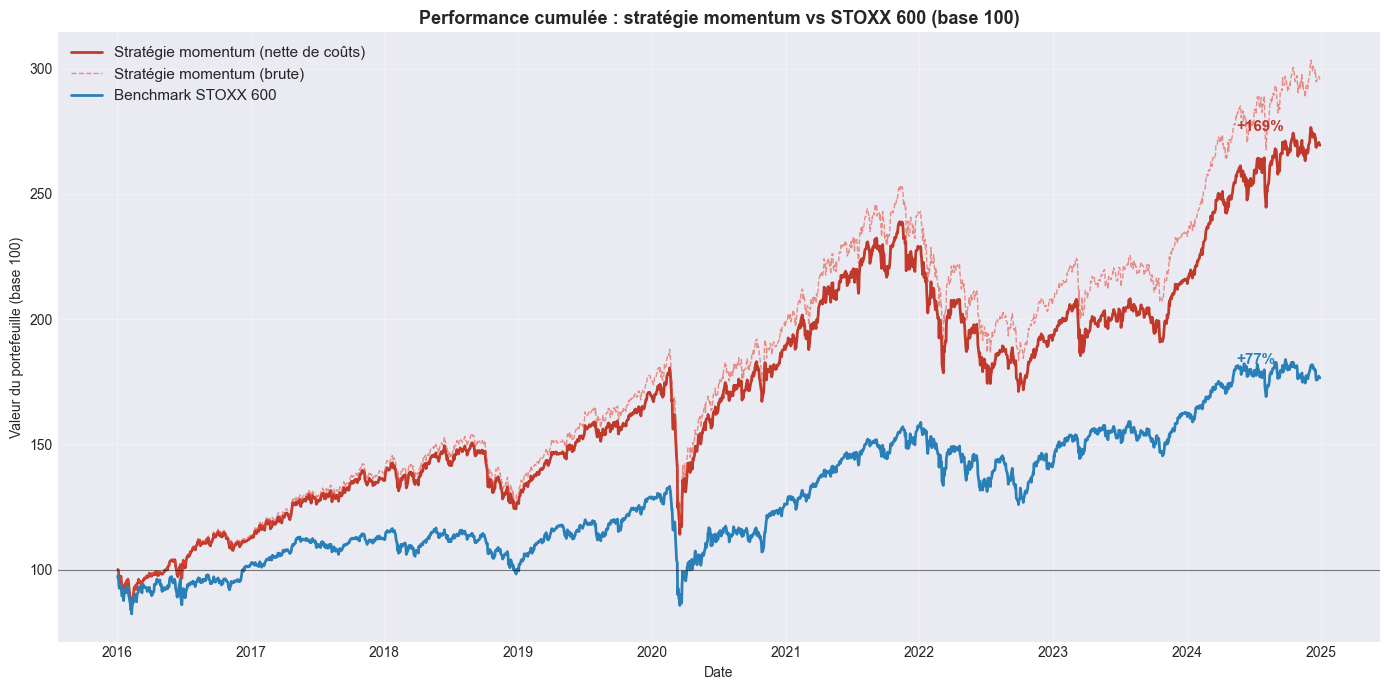

Graphique sauvegardé.


In [6]:
# Graphique de performance cumulée : stratégie vs benchmark
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(cum_strategy_net.index, cum_strategy_net.values,
        label="Stratégie momentum (nette de coûts)", color="#c0392b", linewidth=2)
ax.plot(cum_strategy_gross.index, cum_strategy_gross.values,
        label="Stratégie momentum (brute)", color="#e74c3c", linewidth=1,
        linestyle="--", alpha=0.6)
ax.plot(cum_benchmark.index, cum_benchmark.values,
        label="Benchmark STOXX 600", color="#2980b9", linewidth=2)

ax.axhline(100, color="black", linewidth=0.8, alpha=0.5)
ax.set_title("Performance cumulée : stratégie momentum vs STOXX 600 (base 100)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Valeur du portefeuille (base 100)")
ax.legend(loc="upper left", fontsize=11)
ax.grid(True, alpha=0.3)

# Annotation de la performance finale
ax.annotate(f"+{cum_strategy_net.iloc[-1]-100:.0f}%",
            xy=(cum_strategy_net.index[-1], cum_strategy_net.iloc[-1]),
            xytext=(-60, 10), textcoords="offset points",
            fontsize=11, fontweight="bold", color="#c0392b")
ax.annotate(f"+{cum_benchmark.iloc[-1]-100:.0f}%",
            xy=(cum_benchmark.index[-1], cum_benchmark.iloc[-1]),
            xytext=(-60, 10), textcoords="offset points",
            fontsize=11, fontweight="bold", color="#2980b9")

plt.tight_layout()
plt.savefig(FIGURES / "03_performance_cumulee.png", dpi=150, bbox_inches="tight")
plt.show()

print("Graphique sauvegardé.")

### Lecture de la performance cumulée

Sur la période 2016-2024, la stratégie momentum (nette de coûts) génère un rendement total de +169 %, contre +77 % pour le benchmark STOXX 600, soit une surperformance de 93 points de pourcentage.

**Une surperformance persistante**  
L'écart entre la stratégie et le benchmark se creuse de façon continue sur l'ensemble de la période, plutôt que d'être concentré sur un épisode isolé. Cette régularité renforce la crédibilité du signal momentum, même si elle doit être interprétée à la lumière du biais de survie (voir ci-dessous).

**Le momentum crash de mars 2020**  
Lors du krach Covid, la stratégie décroche plus fortement que le benchmark. Ce comportement illustre le « momentum crash » documenté par Daniel & Moskowitz (2016) : lors des retournements brutaux de marché, les stratégies momentum souffrent davantage car elles sont concentrées sur les titres qui performaient avant le choc, lesquels sont les plus pénalisés lors du retournement. La stratégie récupère toutefois rapidement et reprend sa trajectoire de surperformance.

**Impact des coûts de transaction**  
L'écart entre la performance brute et nette (courbes rouges pleine et pointillée) reste modéré et s'élargit progressivement avec l'accumulation des coûts. Le turnover annualisé de 351 % génère un coût d'environ 1,14 point de pourcentage par an, qui n'entame pas significativement la surperformance.

**Réserve méthodologique importante : le biais de survie (survivorship bias)**  
La composition de l'univers d'investissement est celle de l'indice en 2026. Les titres sortis de l'indice avant cette date (faillites, délistages, exclusions) ne sont pas inclus. Comme la stratégie momentum sélectionne les titres gagnants, et que les survivants sont par construction surreprésentés parmi les gagnants, une partie de la surperformance observée est imputable à ce biais de survie, et non au seul signal momentum. La littérature estime que ce biais peut gonfler les rendements de 1 à 4 points de pourcentage par an.
La surperformance « réelle » est donc vraisemblablement inférieure à celle mesurée ici. Une analyse sans biais nécessiterait la composition historique mensuelle de l'indice.

In [7]:
# Calcul des métriques de performance et de risque
# Fonction réutilisable pour la stratégie ET le benchmark

def compute_metrics(daily_returns, name, rf_annual=0.0):
    """Calcule les métriques de performance standard à partir des rendements quotidiens."""
    daily_returns = daily_returns.dropna()
    
    # Rendement annualisé (géométrique)
    n_years = len(daily_returns) / 252
    total_return = (1 + daily_returns).prod() - 1
    ann_return = (1 + total_return) ** (1 / n_years) - 1
    
    # Volatilité annualisée
    ann_vol = daily_returns.std() * np.sqrt(252)
    
    # Ratio de Sharpe (avec taux sans risque)
    rf_daily = (1 + rf_annual) ** (1/252) - 1
    excess_returns = daily_returns - rf_daily
    sharpe = (excess_returns.mean() / daily_returns.std()) * np.sqrt(252)
    
    # Maximum drawdown
    cum = (1 + daily_returns).cumprod()
    running_max = cum.cummax()
    drawdown = (cum - running_max) / running_max
    max_dd = drawdown.min()
    
    # Durée du max drawdown (en jours)
    dd_end = drawdown.idxmin()
    dd_start = cum[:dd_end].idxmax()
    dd_duration = (dd_end - dd_start).days
    
    # Ratio de Calmar (rendement annualisé / max drawdown)
    calmar = ann_return / abs(max_dd) if max_dd != 0 else np.nan
    
    # % de jours positifs
    pct_positive = (daily_returns > 0).mean()
    
    return {
        "Stratégie": name,
        "Rendement annualisé": f"{ann_return*100:.2f}%",
        "Volatilité annualisée": f"{ann_vol*100:.2f}%",
        "Ratio de Sharpe": f"{sharpe:.3f}",
        "Max Drawdown": f"{max_dd*100:.2f}%",
        "Durée Max DD (jours)": dd_duration,
        "Ratio de Calmar": f"{calmar:.3f}",
        "% jours positifs": f"{pct_positive*100:.1f}%",
    }

# Calcul pour les trois séries
metrics = []
metrics.append(compute_metrics(portfolio_returns, "Momentum (brut)"))
metrics.append(compute_metrics(portfolio_returns_net, "Momentum (net)"))
metrics.append(compute_metrics(bench_returns, "STOXX 600 (benchmark)"))

metrics_df = pd.DataFrame(metrics).set_index("Stratégie")

print("=" * 80)
print("MÉTRIQUES DE PERFORMANCE ET DE RISQUE (2016-2024)")
print("=" * 80)
print(metrics_df.T.to_string())

# Sauvegarde
metrics_df.to_csv(TABLES / "03_performance_metrics.csv")
print(f"\nTableau sauvegardé : {TABLES / '03_performance_metrics.csv'}")

MÉTRIQUES DE PERFORMANCE ET DE RISQUE (2016-2024)
Stratégie             Momentum (brut) Momentum (net) STOXX 600 (benchmark)
Rendement annualisé            12.47%         11.34%                 6.46%
Volatilité annualisée          16.11%         16.10%                16.24%
Ratio de Sharpe                 0.811          0.749                 0.467
Max Drawdown                  -36.75%        -36.81%               -35.70%
Durée Max DD (jours)               28             28                    28
Ratio de Calmar                 0.339          0.308                 0.181
% jours positifs                56.7%          56.4%                 53.8%

Tableau sauvegardé : C:\Users\volka\Documents\momentum-strategy-stoxx600\output\tables\03_performance_metrics.csv


### Lecture des métriques de risque

Le tableau compare la stratégie momentum (brute et nette) au benchmark STOXX 600 
sur 2016-2024.

**Le ratio de Sharpe : l'argument central**  
La stratégie nette affiche un ratio de Sharpe de 0,749, contre 0,467 pour le benchmark. Cet écart est d'autant plus significatif que les volatilités annualisées des deux séries sont quasi identiques (16,1 % contre 16,2 %). La surperformance ne provient donc pas d'une prise de risque accrue : à niveau de risque comparable, la stratégie génère un rendement supérieur. C'est la signature d'un véritable alpha ajusté du risque.

**Maximum drawdown : un risque de baisse comparable**  
Le maximum drawdown de la stratégie (−36,8 %) est légèrement supérieur à celui du benchmark (−35,7 %), avec une durée identique (28 jours). Ce drawdown correspond au krach de mars 2020. Le momentum est donc marginalement plus exposé aux retournements brutaux, conformément au phénomène de momentum crash, mais sans dégradation majeure du profil de risque de baisse.

**Ratio de Calmar**  
Le ratio de Calmar (rendement annualisé rapporté au maximum drawdown) s'établit à 0,308 pour la stratégie nette contre 0,181 pour le benchmark. Même en pénalisant le rendement par la pire perte subie, la stratégie conserve un avantage net.

**Réserve : impact du biais de survie sur le Sharpe**  
Comme pour le rendement, ces métriques sont vraisemblablement affectées à la hausse par le biais de survie de l'univers (composition 2026). Le Sharpe réel, sans biais, serait probablement inférieur. Toutefois, l'écart avec le benchmark est suffisamment large pour que la conclusion qualitative — une surperformance ajustée du risque — demeure plausible même après correction partielle du biais.

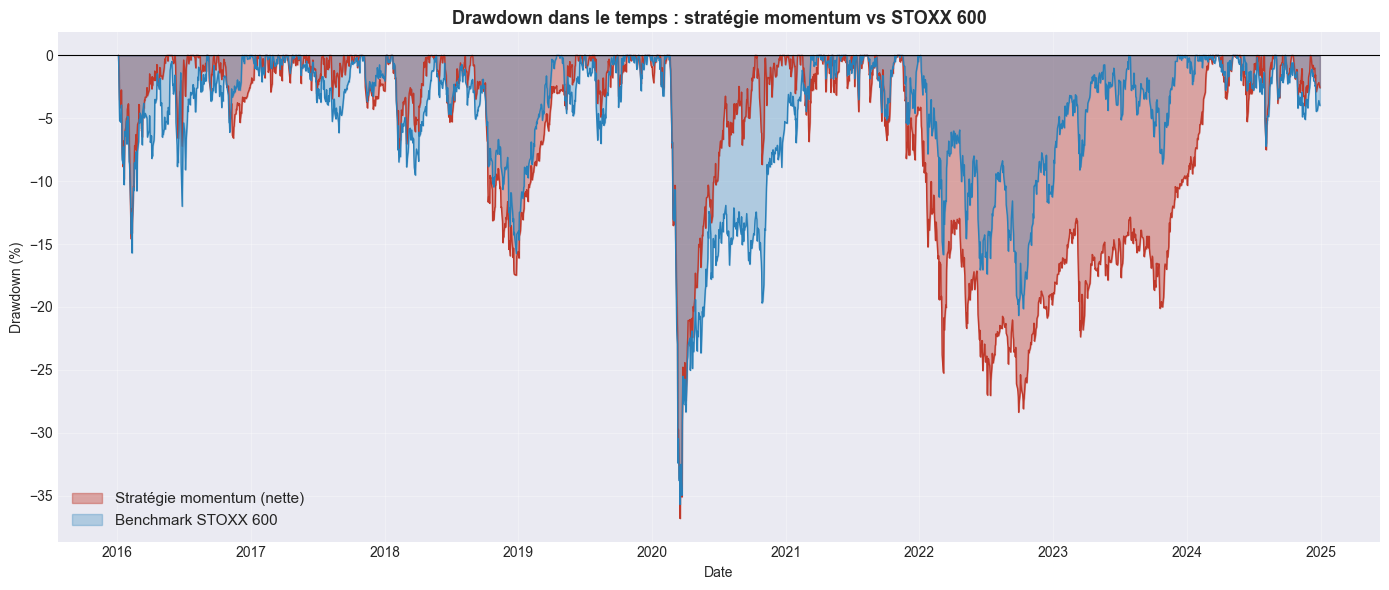

Graphique du drawdown sauvegardé.


In [8]:
# Graphique du drawdown dans le temps : stratégie vs benchmark

def compute_drawdown(daily_returns):
    """Calcule la série de drawdown à partir des rendements quotidiens."""
    cum = (1 + daily_returns.dropna()).cumprod()
    running_max = cum.cummax()
    drawdown = (cum - running_max) / running_max
    return drawdown

dd_strategy = compute_drawdown(portfolio_returns_net)
dd_benchmark = compute_drawdown(bench_returns)

fig, ax = plt.subplots(figsize=(14, 6))

ax.fill_between(dd_strategy.index, dd_strategy.values * 100, 0,
                color="#c0392b", alpha=0.4, label="Stratégie momentum (nette)")
ax.fill_between(dd_benchmark.index, dd_benchmark.values * 100, 0,
                color="#2980b9", alpha=0.3, label="Benchmark STOXX 600")

ax.plot(dd_strategy.index, dd_strategy.values * 100, color="#c0392b", linewidth=1)
ax.plot(dd_benchmark.index, dd_benchmark.values * 100, color="#2980b9", linewidth=1)

ax.set_title("Drawdown dans le temps : stratégie momentum vs STOXX 600",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Drawdown (%)")
ax.legend(loc="lower left", fontsize=11)
ax.grid(True, alpha=0.3)
ax.axhline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.savefig(FIGURES / "03_drawdown.png", dpi=150, bbox_inches="tight")
plt.show()

print("Graphique du drawdown sauvegardé.")

### Lecture du drawdown dans le temps

Le graphique de drawdown révèle deux régimes de risque distincts, plus nuancés que ne le suggère la seule courbe de performance.

**Mars 2020 : un crash brutal mais bref**  
Lors du krach Covid, la stratégie momentum atteint un drawdown de −37 %, légèrement supérieur à celui du benchmark (−35 %). Ce décrochage correspond au momentum crash. La récupération est toutefois rapide : les deux séries reviennent près de leur sommet dès l'été 2020.

**2022-2023 : un drawdown long lié à la rotation de marché**  
La période de resserrement monétaire de 2022 provoque un drawdown plus prolongé pour la stratégie momentum, qui met près de dix-huit mois à récupérer. Ce comportement reflète la rotation sectorielle de cette période : la hausse des taux a pénalisé les titres de croissance qui dominaient le portefeuille momentum, au profit des titres value. La stratégie a mis du temps à se réadapter aux nouveaux leaders de marché.

**Périodes normales : un risque maîtrisé**  
En dehors de ces deux épisodes, les drawdowns restent modérés (−5 % à −15 %) et comparables à ceux du benchmark. La stratégie ne présente donc pas de fragilité structurelle permanente ; son risque de baisse se concentre sur les phases de retournement brutal ou de rotation de régime de marché.

**Implication**  
Ce profil de risque — performance supérieure en régime normal, vulnérabilité accrue lors des retournements — est caractéristique des stratégies momentum et cohérent avec la littérature. Il souligne l'intérêt potentiel d'un overlay de gestion du risque (filtres de tendance, ajustement de l'exposition en période de stress), piste d'extension naturelle du projet.

## Conclusion du notebook 03

Ce notebook a backtesté la stratégie momentum (long-only, top quintile, 
rebalancement mensuel) sur le STOXX Europe 600 entre 2016 et 2024, avec prise 
en compte des coûts de transaction et comparaison au benchmark.

### Résultats de performance

| Métrique | Momentum (net) | STOXX 600 |
|----------|----------------|-----------|
| Rendement total | +169 % | +77 % |
| Rendement annualisé | 11,34 % | 6,46 % |
| Volatilité annualisée | 16,10 % | 16,24 % |
| Ratio de Sharpe | 0,749 | 0,467 |
| Maximum drawdown | −36,8 % | −35,7 % |
| Ratio de Calmar | 0,308 | 0,181 |

### Enseignements principaux

**Une surperformance ajustée du risque**  
La stratégie surperforme le benchmark de près de 5 points de rendement 
annualisé, à volatilité quasi identique. Le ratio de Sharpe (0,749 contre 
0,467) confirme que cette surperformance ne résulte pas d'une prise de risque 
accrue mais d'un véritable alpha.

**Des coûts de transaction maîtrisés**  
Malgré un turnover annualisé élevé (351 %), les coûts de transaction (15 bp 
par trade) ne réduisent la performance que de 1,14 point par an. La stratégie 
reste largement rentable nette de coûts.

**Un profil de risque caractéristique du momentum**  
La stratégie connaît un momentum crash en mars 2020 (drawdown de −37 %, 
récupération rapide) et un drawdown prolongé en 2022-2023 lié à la rotation 
de marché provoquée par le resserrement monétaire. En dehors de ces épisodes, 
son risque de baisse est comparable à celui du marché.

### Limite majeure : le biais de survie (survivorship bias)

La conclusion la plus importante de ce notebook est aussi sa principale 
réserve. L'univers d'investissement repose sur la composition de l'indice en 
2026 ; les titres sortis de l'indice avant cette date ne sont pas inclus. La 
stratégie momentum sélectionnant les titres gagnants, et les survivants étant 
surreprésentés parmi ceux-ci, une part indéterminée de la surperformance est 
imputable à ce biais plutôt qu'au signal momentum lui-même.

La littérature estime ce biais entre 1 et 4 points de rendement annualisé. 
La surperformance « réelle » est donc vraisemblablement inférieure à celle 
mesurée. Toutefois, l'ampleur de l'écart observé (près de 5 points de 
rendement, +0,28 de Sharpe) suggère qu'une surperformance subsisterait même 
après correction partielle du biais.

### Prochaine étape

Notebook 04 : analyse de performance approfondie — décomposition par sous-période, 
comparaison au facteur momentum académique (WML de Ken French), et analyse de 
la robustesse du signal selon la fenêtre de calcul (3M, 6M, 12M).